# Preprocessing

## Loading Data from Kaggle

In [176]:
!python -m pip install kagglehub


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [177]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dartweichen/student-life")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\malen\.cache\kagglehub\datasets\dartweichen\student-life\versions\1


## Stress Component

Defining path for the data regarding stress

In [178]:
import os

path = r"C:\Users\malen\.cache\kagglehub\datasets\dartweichen\student-life\versions\1\dataset"
stress_path = os.path.join(path, "EMA", "response", "Stress")

files = os.listdir(stress_path)
print(files[:10])

['Stress_u00.json', 'Stress_u01.json', 'Stress_u02.json', 'Stress_u03.json', 'Stress_u04.json', 'Stress_u05.json', 'Stress_u07.json', 'Stress_u08.json', 'Stress_u09.json', 'Stress_u10.json']


Looking at the first file to see if it works before moving on

In [179]:
import pandas as pd

file = files[0]  # pick first actual file
full_path = os.path.join(stress_path, file)

print("Loading:", full_path)

df = pd.read_json(full_path)

print(df.head())
print(df.columns)

Loading: C:\Users\malen\.cache\kagglehub\datasets\dartweichen\student-life\versions\1\dataset\EMA\response\Stress\Stress_u00.json
                       null           resp_time  level location
0  43.75908069,-72.32885314 2013-03-24 08:40:01    NaN      NaN
1  43.75908069,-72.32885314 2013-03-24 08:40:58    NaN      NaN
2  43.70677151,-72.28746626 2013-03-25 02:16:45    NaN      NaN
3                         1 2013-03-25 00:00:18    NaN      NaN
4                         1 2013-03-25 02:16:49    NaN      NaN
Index(['null', 'resp_time', 'level', 'location'], dtype='str')


In [180]:
import json

with open(full_path) as f:
    data = json.load(f)

print(type(data))
print(data[:2] if isinstance(data, list) else data)

<class 'list'>
[{'null': '43.75908069,-72.32885314', 'resp_time': 1364114401}, {'null': '43.75908069,-72.32885314', 'resp_time': 1364114458}]


In [181]:
import pandas as pd
import os

# Load file
file = "Stress_u00.json"
stress_path = r"C:\Users\malen\.cache\kagglehub\datasets\dartweichen\student-life\versions\1\dataset\EMA\response\Stress"

df = pd.read_json(os.path.join(stress_path, file))

print(df.head())

                       null           resp_time  level location
0  43.75908069,-72.32885314 2013-03-24 08:40:01    NaN      NaN
1  43.75908069,-72.32885314 2013-03-24 08:40:58    NaN      NaN
2  43.70677151,-72.28746626 2013-03-25 02:16:45    NaN      NaN
3                         1 2013-03-25 00:00:18    NaN      NaN
4                         1 2013-03-25 02:16:49    NaN      NaN


In [182]:
df['time'] = pd.to_datetime(df['resp_time'], unit='s')

In [183]:
df['level']

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
     ... 
74    1.0
75    1.0
76    3.0
77    1.0
78    2.0
Name: level, Length: 79, dtype: float64

In [184]:
df_clean = df.dropna(subset=['level'])

In [185]:
df_clean['level'] = pd.to_numeric(df_clean['level'], errors='coerce')
df_clean = df_clean.dropna(subset=['level'])

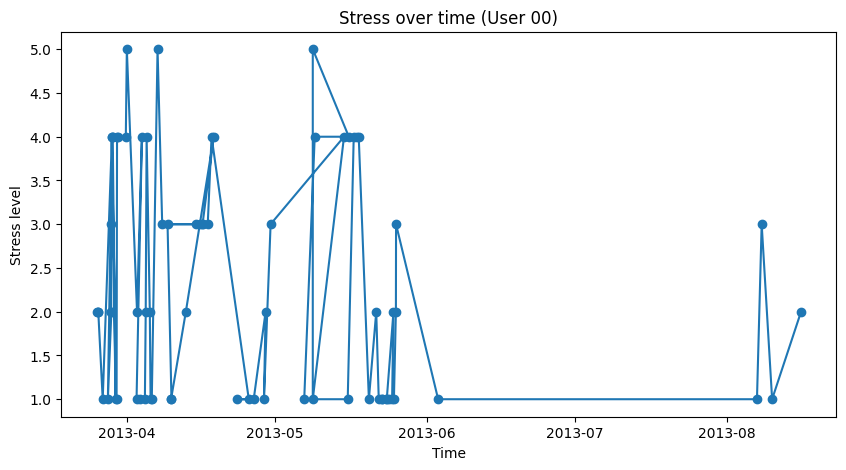

In [186]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df_clean['time'], df_clean['level'], marker='o')
plt.title("Stress over time (User 00)")
plt.xlabel("Time")
plt.ylabel("Stress level")
plt.show()

In [187]:
print("Total rows:", len(df))
print("Valid stress responses:", len(df_clean))

Total rows: 79
Valid stress responses: 74


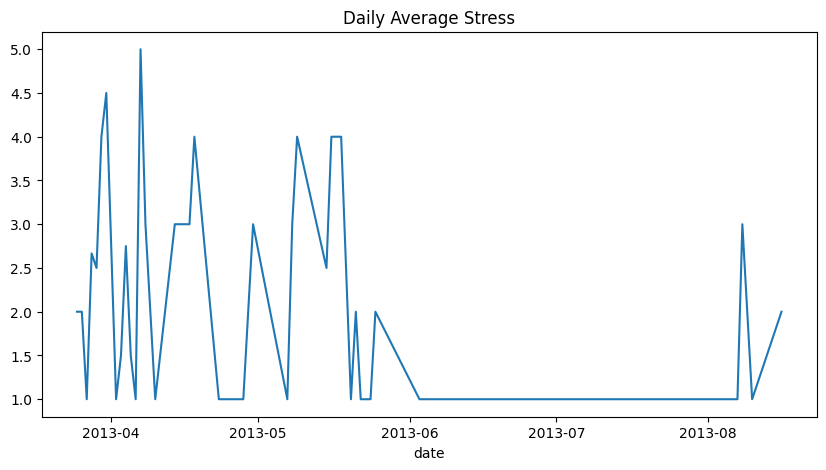

In [188]:
df_clean['date'] = df_clean['time'].dt.date

daily_stress = df_clean.groupby('date')['level'].mean()

daily_stress.plot(figsize=(10,5), title="Daily Average Stress")
plt.show()

Loading all stress data for all participants into all_data

In [189]:
all_data = [] #CHANGE TO ALL_DATA_STRESS OR SOMETHING FOR TRANSPARENCY

for file in os.listdir(stress_path):
    df = pd.read_json(os.path.join(stress_path, file))
    
    # 🔍 Check columns FIRST
    if 'level' not in df.columns or 'resp_time' not in df.columns:
        print(f"Skipping {file} (missing columns)")
        continue
    
    # Clean
    df = df.dropna(subset=['level'])
    df['level'] = pd.to_numeric(df['level'], errors='coerce')
    df = df.dropna(subset=['level'])
    
    # Time
    df['time'] = pd.to_datetime(df['resp_time'], unit='s')
    df['date'] = df['time'].dt.date
    
    # User ID
    df['user'] = file.split('_')[1].split('.')[0]
    
    all_data.append(df[['user', 'date', 'level']])

Skipping Stress_u13.json (missing columns)


In [190]:
print(len(all_data))
print(all_data[0].head())

48
  user        date  level
5  u00  2013-03-25    2.0
6  u00  2013-03-26    2.0
7  u00  2013-03-26    2.0
8  u00  2013-03-27    1.0
9  u00  2013-03-28    4.0


In [191]:
import pandas as pd

stress_all = pd.concat(all_data)

stress_daily = stress_all.groupby(['user', 'date'])['level'].mean().reset_index()

print(stress_daily.head())

  user        date     level
0  u00  2013-03-25  2.000000
1  u00  2013-03-26  2.000000
2  u00  2013-03-27  1.000000
3  u00  2013-03-28  2.666667
4  u00  2013-03-29  2.500000


Visualizing stress level over time - averaged over all students

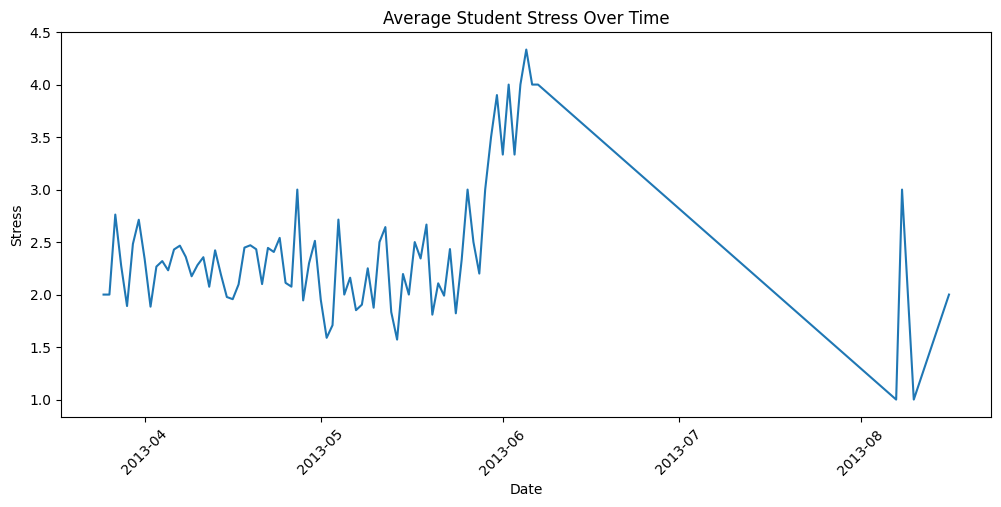

In [192]:
import matplotlib.pyplot as plt

global_stress = stress_daily.groupby('date')['level'].mean()

plt.figure(figsize=(12,5))
plt.plot(global_stress.index, global_stress.values)
plt.title("Average Student Stress Over Time")
plt.xlabel("Date")
plt.ylabel("Stress")
plt.xticks(rotation=45)
plt.show()

Looking at the participants reporting the highest level of stress

In [193]:
top_users = stress_daily.groupby('user')['level'].mean().sort_values(ascending=False).head(5)

print(top_users)

user
u07    3.468358
u49    3.295455
u42    3.271930
u56    3.208333
u45    3.200000
Name: level, dtype: float64


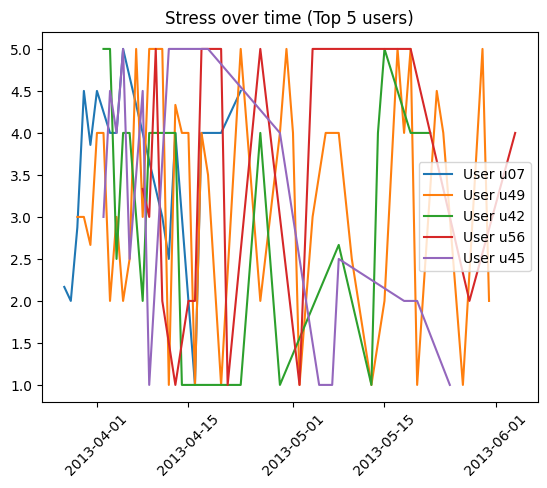

In [194]:
top_list = top_users.index

subset = stress_daily[stress_daily['user'].isin(top_list)]

for u in top_list:
    user_data = subset[subset['user'] == u]
    plt.plot(user_data['date'], user_data['level'], label=f"User {u}")

plt.legend()
plt.title("Stress over time (Top 5 users)")
plt.xticks(rotation=45)
plt.show()

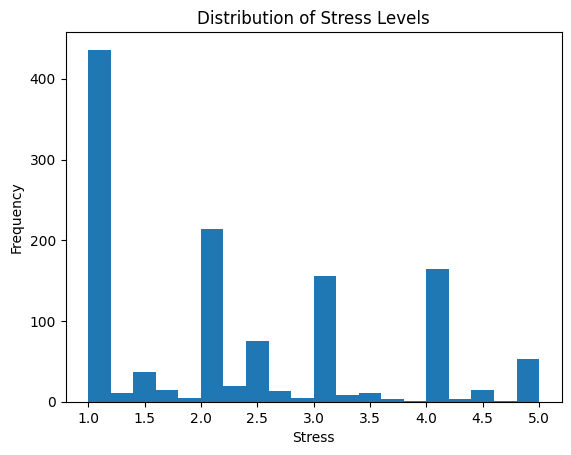

In [195]:
plt.hist(stress_daily['level'], bins=20)
plt.title("Distribution of Stress Levels")
plt.xlabel("Stress")
plt.ylabel("Frequency")
plt.show()

# Looking at dealines

Loading data for deadlines

In [196]:
deadlines = pd.read_csv(
    r"C:\Users\malen\.cache\kagglehub\datasets\dartweichen\student-life\versions\1\dataset\education\deadlines.csv"
)

# Rename uid → user (WHYYYY???)
deadlines = deadlines.rename(columns={'uid': 'user'})

# Convert from wide to long
deadlines_long = deadlines.melt(
    id_vars='user',
    var_name='date',
    value_name='workload'
)

# Fix types
deadlines_long['date'] = pd.to_datetime(deadlines_long['date']).dt.date
deadlines_long['workload'] = pd.to_numeric(deadlines_long['workload'], errors='coerce')

print(deadlines_long.head())

  user        date  workload
0  u01  2013-03-27       0.0
1  u02  2013-03-27       0.0
2  u03  2013-03-27       0.0
3  u04  2013-03-27       0.0
4  u05  2013-03-27       0.0


In [197]:
merged = stress_daily.merge(
    deadlines_long,
    on=['user', 'date'],
    how='left'
)

#merged['workload'] = merged['workload'].fillna(0)

Seeing if there is a connection between workload and level of stress reported from the dates

In [198]:
merged.groupby('workload')['level'].mean()

workload
0.0    2.288973
1.0    2.179677
2.0    2.465258
3.0    2.166667
Name: level, dtype: float64

Splitting data into high and low workload with split around 2

In [199]:
merged['high_pressure'] = merged['workload'] >= 2

In [200]:
merged.groupby('high_pressure')['level'].mean()

high_pressure
False    2.240055
True     2.432978
Name: level, dtype: float64

Here we see that level of stress is a little higher when the workload is higher

# Social stuff

Loading data for social interactions during the day

In [201]:
import pandas as pd
import os

social_path = r"C:\Users\malen\.cache\kagglehub\datasets\dartweichen\student-life\versions\1\dataset\EMA\response\Social"

all_social = []

for file in os.listdir(social_path):
    df = pd.read_json(os.path.join(social_path, file))
    
    # Only keep valid rows
    if 'number' not in df.columns:
        continue
    
    #df = df.dropna(subset=['number'])
    
    # Convert
    df['social'] = pd.to_numeric(df['number'], errors='coerce')
    #df = df.dropna(subset=['social'])
    
    # Time
    df['time'] = pd.to_datetime(df['resp_time'], unit='s')
    df['date'] = df['time'].dt.date
    
    # User ID
    df['user'] = file.split('_')[1].split('.')[0]
    
    all_social.append(df[['user', 'date', 'social']])

social_all = pd.concat(all_social)

In [202]:
social_all.head(10)

,user,date,social
0,u00,2013-03-24,NaN
1,u00,2013-03-24,NaN
2,u00,2013-03-24,NaN
3,u00,2013-03-25,NaN
4,u00,2013-03-24,NaN
5,u00,2013-03-26,5.0
6,u00,2013-03-26,1.0
7,u00,2013-03-26,1.0
8,u00,2013-04-03,3.0
9,u00,2013-03-27,4.0


In [203]:
social_daily = social_all.groupby(['user', 'date'])['social'].mean().reset_index()
print(social_daily.head())

  user        date    social
0  u00  2013-03-24       NaN
1  u00  2013-03-25       NaN
2  u00  2013-03-26  2.333333
3  u00  2013-03-27  4.000000
4  u00  2013-03-28  3.000000


In [204]:
merged = merged.merge(
    social_daily,
    on=['user', 'date'],
    how='left'
)

In [205]:
merged.groupby('workload')[['level', 'social']].mean()

,level,social
workload,,
0.0,2.288973,3.010932
1.0,2.179677,3.056738
2.0,2.465258,3.487879
3.0,2.166667,3.750000


In [206]:
threshold_work = merged['workload'].quantile(0.9)
threshold_social = merged['social'].median()

merged['high_workload'] = merged['workload'] >= threshold_work
merged['high_social'] = merged['social'] > threshold_social

merged.groupby(['high_workload', 'high_social'])['level'].mean()

high_workload  high_social
False          False          2.205127
               True           2.463427
True           False          2.269006
               True           2.151210
Name: level, dtype: float64

## Sleep Stuff

In [207]:
import pandas as pd
import os

sleep_path = r"C:\Users\malen\.cache\kagglehub\datasets\dartweichen\student-life\versions\1\dataset\EMA\response\Sleep"

all_sleep = []

for file in os.listdir(sleep_path):
    df = pd.read_json(os.path.join(sleep_path, file))
    
    # Keep only rows with actual sleep info
    if 'hour' not in df.columns:
        continue
    
    #df = df.dropna(subset=['hour'])
    
    # Convert sleep hours
    df['sleep'] = pd.to_numeric(df['hour'], errors='coerce')
    #df = df.dropna(subset=['sleep'])
    
    # Time
    df['time'] = pd.to_datetime(df['resp_time'], unit='s')
    df['date'] = df['time'].dt.date
    
    # User
    df['user'] = file.split('_')[1].split('.')[0]
    
    all_sleep.append(df[['user', 'date', 'sleep']])

In [208]:
if len(all_sleep) == 0:
    print("Still no sleep data — check again")
else:
    sleep_all = pd.concat(all_sleep)

In [209]:
sleep_daily = sleep_all.groupby(['user', 'date'])['sleep'].mean().reset_index()

print(sleep_daily.head())

  user        date  sleep
0  u00  2013-03-24    NaN
1  u00  2013-03-25    8.0
2  u00  2013-03-26    7.5
3  u00  2013-03-27    8.0
4  u00  2013-03-28    6.5


In [210]:
merged = merged.merge(
    sleep_daily,
    on=['user', 'date'],
    how='left'
)

In [211]:
merged_clean = merged.dropna(subset=['level'])

threshold_work = merged_clean['workload'].quantile(0.9)
threshold_social = merged_clean['social'].median()
threshold_sleep = merged_clean['sleep'].median()

merged_clean['high_workload'] = merged_clean['workload'] >= threshold_work
merged_clean['high_social'] = merged_clean['social'] > threshold_social
merged_clean['good_sleep'] = merged_clean['sleep'] > threshold_sleep

merged_clean.groupby(
    ['high_workload', 'high_social', 'good_sleep']
)['level'].mean()

high_workload  high_social  good_sleep
False          False        False         2.184247
                            True          2.244791
               True         False         2.459851
                            True          2.469403
True           False        False         2.420427
                            True          1.880990
               True         False         2.295689
                            True          1.746667
Name: level, dtype: float64

In [212]:
result_df = merged_clean.reset_index()
print(result_df)

      index user        date     level  workload  high_pressure    social  \
0         0  u00  2013-03-25  2.000000       NaN          False       NaN   
1         1  u00  2013-03-26  2.000000       NaN          False  2.333333   
2         2  u00  2013-03-27  1.000000       NaN          False  4.000000   
3         3  u00  2013-03-28  2.666667       NaN          False  3.000000   
4         4  u00  2013-03-29  2.500000       NaN          False  4.000000   
...     ...  ...         ...       ...       ...            ...       ...   
1239   1239  u59  2013-06-03  4.000000       0.0          False       NaN   
1240   1240  u59  2013-06-04  4.000000       0.0          False  3.000000   
1241   1241  u59  2013-06-05  4.333333       0.0          False       NaN   
1242   1242  u59  2013-06-06  4.000000       NaN          False  3.000000   
1243   1243  u59  2013-06-07  4.000000       NaN          False  3.000000   

      high_workload  high_social  sleep  good_sleep  
0             False  

Comapre indivisually

In [213]:
merged_clean.groupby('high_workload')['level'].mean()

high_workload
False    2.253339
True     2.245447
Name: level, dtype: float64

In [214]:
merged_clean.groupby('high_social')['level'].mean(
)

high_social
False    2.219576
True     2.388018
Name: level, dtype: float64

In [215]:
merged_clean.groupby('good_sleep')['level'].mean()

good_sleep
False    2.273851
True     2.206945
Name: level, dtype: float64

In [216]:
merged_clean[['level', 'workload', 'social', 'sleep']].corr()

,level,workload,social,sleep
level,1.000000,0.001669,0.131148,-0.029798
workload,0.001669,1.000000,0.099322,-0.215002
social,0.131148,0.099322,1.000000,-0.061581
sleep,-0.029798,-0.215002,-0.061581,1.000000


## Stress Survey (static per participant)

In [217]:
survey = pd.read_csv("C:/Users/malen/.cache/kagglehub/datasets/dartweichen/student-life/versions/1/dataset/survey/PerceivedStressScale.csv")

In [218]:
survey.head(5)

,uid,type,"1. In the last month, how often have you been upset because of something that happened unexpectedly?","2. In the last month, how often have you felt that you were unable to control the important things in your life?","3. In the last month, how often have you felt nervous and ""stressed""?","4. In the last month, how often have you felt confident about your ability to handle your personal problems?","5. In the last month, how often have you felt that things were going your way?","6. In the last month, how often have you found that you could not cope with all the things that you had to do?","7. In the last month, how often have you been able to control irritations in your life?","8. In the last month, how often have you felt that you were on top of things?","9. In the last month, how often have you been angered because of things that were outside of your control?","10. In the last month, how often have you felt difficulties were piling up so high that you could not overcome them?"
0,u00,pre,Sometime,Sometime,Fairly often,Fairly often,Sometime,Very often,Sometime,Sometime,Fairly often,Fairly often
1,u01,pre,Sometime,Sometime,Sometime,Sometime,Fairly often,Sometime,Fairly often,Fairly often,Almost never,Almost never
2,u02,pre,Fairly often,Sometime,Sometime,Fairly often,Almost never,Sometime,Almost never,Sometime,Sometime,Almost never
3,u03,pre,Sometime,Almost never,Sometime,Almost never,Sometime,Never,Almost never,Never,Never,Never
4,u04,pre,Almost never,Almost never,Fairly often,Sometime,Sometime,Fairly often,Sometime,Almost never,Sometime,Sometime


Calculating score based on PercievedStressScale

Figuring Your PSS Score

You can determine your PSS score by following these directions:

• First, reverse your scores for questions 4, 5, 7, and 8. On these 4 questions, change the scores like this:
0 = 4, 1 = 3, 2 = 2, 3 = 1, 4 = 0.

• Now add up your scores for each item to get a total. My total score is ___________.

• Individual scores on the PSS can range from 0 to 40 with higher scores indicating higher perceived stress.

► Scores ranging from 0-13 would be considered low stress.

► Scores ranging from 14-26 would be considered moderate stress.

► Scores ranging from 27-40 would be considered high perceived stress.

In [219]:
mapping = {
    "never": 0,
    "almost never": 1,
    "sometime": 2,
    "fairly often": 3,
    "very often": 4
}

survey_numeric = survey.copy()

for col in survey.columns[2:]:
    survey_numeric[col] = (
        survey[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .map(mapping)
    )

question_cols = survey_numeric.columns[2:12]  # Q1–Q10

In [220]:
reverse_indices = [3, 4, 6, 7]

for i in reverse_indices:
    col = question_cols[i]
    survey_numeric[col] = 4 - survey_numeric[col]

In [221]:
survey_numeric['baseline_stress'] = survey_numeric[question_cols].sum(axis=1)

In [222]:
survey_numeric.head(5)

,uid,type,"1. In the last month, how often have you been upset because of something that happened unexpectedly?","2. In the last month, how often have you felt that you were unable to control the important things in your life?","3. In the last month, how often have you felt nervous and ""stressed""?","4. In the last month, how often have you felt confident about your ability to handle your personal problems?","5. In the last month, how often have you felt that things were going your way?","6. In the last month, how often have you found that you could not cope with all the things that you had to do?","7. In the last month, how often have you been able to control irritations in your life?","8. In the last month, how often have you felt that you were on top of things?","9. In the last month, how often have you been angered because of things that were outside of your control?","10. In the last month, how often have you felt difficulties were piling up so high that you could not overcome them?",baseline_stress
0,u00,pre,2,2,3.0,1,2.0,4,2,2,3,3,24.0
1,u01,pre,2,2,2.0,2,1.0,2,1,1,1,1,15.0
2,u02,pre,3,2,2.0,1,3.0,2,3,2,2,1,21.0
3,u03,pre,2,1,2.0,3,2.0,0,3,4,0,0,17.0
4,u04,pre,1,1,3.0,2,2.0,3,2,3,2,2,21.0


In [223]:
#Create Categories:
def categorize_stress(score):
    if score <= 13:
        return "low"
    elif score <= 26:
        return "moderate"
    else:
        return "high"

survey_numeric['stress_category'] = survey_numeric['baseline_stress'].apply(categorize_stress)

In [224]:
print(survey_numeric[['baseline_stress', 'stress_category']].head())
print(survey_numeric['baseline_stress'].describe())

   baseline_stress stress_category
0             24.0        moderate
1             15.0        moderate
2             21.0        moderate
3             17.0        moderate
4             21.0        moderate
count    85.000000
mean     18.470588
std       6.912012
min       3.000000
25%      14.000000
50%      18.000000
75%      23.000000
max      34.000000
Name: baseline_stress, dtype: float64


Merge into the dataset created above

In [225]:
survey_numeric = survey_numeric.rename(columns={'uid': 'user'})

survey_numeric = survey_numeric[survey_numeric['type'] == 'pre']

merged_clean = merged_clean.merge(
    survey_numeric[['user', 'baseline_stress', 'stress_category']],
    on='user',
    how='left'
)

In [226]:
merged_clean.head(5)

,user,date,level,workload,high_pressure,social,high_workload,high_social,sleep,good_sleep,baseline_stress,stress_category
0,u00,2013-03-25,2.000000,NaN,False,NaN,False,False,8.0,True,24.0,moderate
1,u00,2013-03-26,2.000000,NaN,False,2.333333,False,False,7.5,True,24.0,moderate
2,u00,2013-03-27,1.000000,NaN,False,4.000000,False,True,8.0,True,24.0,moderate
3,u00,2013-03-28,2.666667,NaN,False,3.000000,False,False,6.5,False,24.0,moderate
4,u00,2013-03-29,2.500000,NaN,False,4.000000,False,True,6.0,False,24.0,moderate


In [227]:
#Compare on basis of baseline_stress
merged_clean.groupby('stress_category')['level'].mean()

stress_category
high        2.441016
low         2.384944
moderate    2.183944
Name: level, dtype: float64

## Adding mood

In [228]:
# Looking at the EMAs and what they contain

import json

ema_definition_path = response_path = r"C:\Users\malen\.cache\kagglehub\datasets\dartweichen\student-life\versions\1\dataset\EMA\EMA_definition.json"

with open(ema_definition_path, 'r') as f:
    ema_defs = json.load(f)

for item in ema_defs:
    text = str(item).lower()

    if 'mood' in text:
        print("\n----------------")
        print(item)


----------------
{'name': 'Mood', 'questions': [{'options': '(Yes) 1 2 (No)', 'question_id': 'happyornot', 'question_text': 'Do you feel AT ALL happy right now?'}, {'options': '[1]a little bit, [2]somewhat, [3]very much, [4]extremely, ', 'question_id': 'happy', 'question_text': 'If you answered "Yes" on the first question, how happy do you feel? '}, {'options': '(Yes) 1 2 (No)', 'question_id': 'sadornot', 'question_text': 'Do you feel AT ALL sad right now? '}, {'options': '[1]a little bit, [2]somewhat, [3]very much, [4]extremely, ', 'question_id': 'sad', 'question_text': 'If you answered "Yes" on the third question, how sad do you feel?'}, {'options': '', 'question_id': 'location', 'question_text': ''}]}

----------------
{'name': 'Mood 2', 'questions': [{'options': '[1]happy, [2]stressed, [3]tired, ', 'question_id': 'how', 'question_text': 'How are you right now?'}, {'options': '', 'question_id': 'location', 'question_text': ''}]}

----------------
{'name': 'Mood 1', 'questions': [{'

In [229]:
# Define Paths

base_path = r"C:\Users\malen\.cache\kagglehub\datasets\dartweichen\student-life\versions\1\dataset\EMA\response"

mood_path = os.path.join(base_path, "Mood")
mood1_path = os.path.join(base_path, "Mood 1")
mood2_path = os.path.join(base_path, "Mood 2")

### Part 1 - Create Mood Valence

happy - sad

- Positive values indicate positive mood
- Negative values indicate negative mood

In [230]:
all_mood = []

for file in os.listdir(mood_path):

    try:
        df = pd.read_json(os.path.join(mood_path, file))

        # Skip broken files
        if 'happy' not in df.columns or 'sad' not in df.columns:
            print(f"Skipping {file}")
            continue

        # Convert numeric
        df['happy'] = pd.to_numeric(df['happy'], errors='coerce')
        df['sad'] = pd.to_numeric(df['sad'], errors='coerce')

        # Mood valence
        df['mood_valence'] = df['happy'] - df['sad']

        # Date
        df['date'] = pd.to_datetime(
            df['resp_time'],
            unit='s'
        ).dt.date

        # User
        df['user'] = file.split('_')[1].split('.')[0]

        all_mood.append(
            df[['user', 'date', 'mood_valence']]
        )

    except Exception as e:
        print(f"Error in {file}: {e}")

# Combine
mood_all = pd.concat(all_mood)

# Daily average
mood_daily = (
    mood_all
    .groupby(['user', 'date'])['mood_valence']
    .mean()
    .reset_index()
)

print(mood_daily.head())

Skipping Mood_u05.json
Skipping Mood_u09.json
Skipping Mood_u13.json
Skipping Mood_u15.json
Skipping Mood_u20.json
Skipping Mood_u25.json
Skipping Mood_u31.json
Skipping Mood_u34.json
Skipping Mood_u39.json
Skipping Mood_u41.json
Skipping Mood_u54.json
  user        date  mood_valence
0  u00  2013-04-25          -2.0
1  u00  2013-05-15           2.0
2  u00  2013-05-16           1.0
3  u00  2013-05-17           1.0
4  u00  2013-05-21           0.0


### Part 2 - How are you right now?

Responses:

- 1 = happy
- 2 = stressed
- 3 = tired

In [231]:
all_mood2 = []

for file in os.listdir(mood2_path):

    try:
        df = pd.read_json(os.path.join(mood2_path, file))

        if 'how' not in df.columns:
            print(f"Skipping {file}")
            continue

        df['how'] = pd.to_numeric(df['how'], errors='coerce')

        # Binary indicators
        df['happy_now'] = (df['how'] == 1).astype(int)
        df['stressed_now'] = (df['how'] == 2).astype(int)
        df['tired_now'] = (df['how'] == 3).astype(int)

        # Date
        df['date'] = pd.to_datetime(
            df['resp_time'],
            unit='s'
        ).dt.date

        # User
        df['user'] = file.split('_')[1].split('.')[0]

        all_mood2.append(
            df[[
                'user',
                'date',
                'happy_now',
                'stressed_now',
                'tired_now'
            ]]
        )

    except Exception as e:
        print(f"Error in {file}: {e}")

# Combine
mood2_all = pd.concat(all_mood2)

# Daily averages
mood2_daily = (
    mood2_all
    .groupby(['user', 'date'])
    [['happy_now', 'stressed_now', 'tired_now']]
    .mean()
    .reset_index()
)

print(mood2_daily.head())

Skipping Mood 2_u05.json
Skipping Mood 2_u07.json
Skipping Mood 2_u09.json
Skipping Mood 2_u13.json
Skipping Mood 2_u15.json
Skipping Mood 2_u20.json
Skipping Mood 2_u25.json
Skipping Mood 2_u30.json
Skipping Mood 2_u31.json
Skipping Mood 2_u39.json
Skipping Mood 2_u50.json
Skipping Mood 2_u54.json
  user        date  happy_now  stressed_now  tired_now
0  u00  2013-05-05        1.0           0.0        0.0
1  u00  2013-05-11        0.0           0.0        1.0
2  u00  2013-05-12        1.0           0.0        0.0
3  u00  2013-05-13        1.0           0.0        0.0
4  u00  2013-05-14        1.0           0.0        0.0


### Part 3 - Mood tomorrow

Same categories as Mood 2

In [232]:
all_mood1 = []

for file in os.listdir(mood1_path):

    try:
        df = pd.read_json(os.path.join(mood1_path, file))

        if 'tomorrow' not in df.columns:
            print(f"Skipping {file}")
            continue

        df['tomorrow'] = pd.to_numeric(
            df['tomorrow'],
            errors='coerce'
        )

        # Binary indicators
        df['expect_happy'] = (
            df['tomorrow'] == 1
        ).astype(int)

        df['expect_stressed'] = (
            df['tomorrow'] == 2
        ).astype(int)

        df['expect_tired'] = (
            df['tomorrow'] == 3
        ).astype(int)

        # Date
        df['date'] = pd.to_datetime(
            df['resp_time'],
            unit='s'
        ).dt.date

        # User
        df['user'] = file.split('_')[1].split('.')[0]

        all_mood1.append(
            df[[
                'user',
                'date',
                'expect_happy',
                'expect_stressed',
                'expect_tired'
            ]]
        )

    except Exception as e:
        print(f"Error in {file}: {e}")

# Combine
mood1_all = pd.concat(all_mood1)

# Daily averages
mood1_daily = (
    mood1_all
    .groupby(['user', 'date'])
    [[
        'expect_happy',
        'expect_stressed',
        'expect_tired'
    ]]
    .mean()
    .reset_index()
)

print(mood1_daily.head())

Skipping Mood 1_u05.json
Skipping Mood 1_u09.json
Skipping Mood 1_u13.json
Skipping Mood 1_u15.json
Skipping Mood 1_u20.json
Skipping Mood 1_u25.json
Skipping Mood 1_u31.json
Skipping Mood 1_u34.json
Skipping Mood 1_u50.json
  user        date  expect_happy  expect_stressed  expect_tired
0  u00  2013-04-25           0.0              1.0           0.0
1  u00  2013-05-01           0.0              0.0           1.0
2  u00  2013-05-03           1.0              0.0           0.0
3  u00  2013-05-27           1.0              0.0           0.0
4  u00  2013-05-28           1.0              0.0           0.0


### Merge the Moods

In [233]:
merged_mood = merged_clean.copy()

merged_mood['date'] = pd.to_datetime(merged_mood['date'])

In [234]:
mood_daily['date'] = pd.to_datetime(mood_daily['date'])
mood2_daily['date'] = pd.to_datetime(mood2_daily['date'])
mood1_daily['date'] = pd.to_datetime(mood1_daily['date'])

In [235]:
def nearest_merge(main_df, other_df):

    merged_list = []

    for user in main_df['user'].unique():

        left = (
            main_df[main_df['user'] == user]
            .sort_values('date')
            .copy()
        )

        right = (
            other_df[other_df['user'] == user]
            .sort_values('date')
            .copy()
        )

        # Remove duplicate user column
        right = right.drop(columns=['user'])

        if len(right) == 0:
            merged_list.append(left)
            continue

        merged = pd.merge_asof(
            left,
            right,
            on='date',
            direction='nearest',
            tolerance=pd.Timedelta("7D")
        )

        merged_list.append(merged)

    return pd.concat(merged_list)

In [236]:
merged_mood = nearest_merge(
    merged_mood,
    mood_daily
)

In [237]:
merged_mood = nearest_merge(
    merged_mood,
    mood2_daily
)

In [238]:
merged_mood = nearest_merge(
    merged_mood,
    mood1_daily
)

In [239]:
print(merged_mood.columns)

Index(['user', 'date', 'level', 'workload', 'high_pressure', 'social',
       'high_workload', 'high_social', 'sleep', 'good_sleep',
       'baseline_stress', 'stress_category', 'mood_valence', 'happy_now',
       'stressed_now', 'tired_now', 'expect_happy', 'expect_stressed',
       'expect_tired'],
      dtype='str')


In [240]:
print(merged_mood[[
    'mood_valence',
    'happy_now',
    'stressed_now',
    'tired_now',
    'expect_stressed'
]].notna().mean())

mood_valence       0.378617
happy_now          0.407556
stressed_now       0.407556
tired_now          0.407556
expect_stressed    0.393891
dtype: float64


## Physical Activity

In [241]:
import pandas as pd
import os

activity_path = r"C:\Users\malen\.cache\kagglehub\datasets\dartweichen\student-life\versions\1\dataset\sensing\activity"

all_activity = []

for file in os.listdir(activity_path):

    if not file.endswith('.csv'):
        continue

    try:
        df = pd.read_csv(os.path.join(activity_path, file))

        # Clean columns
        df.columns = df.columns.str.strip()

        # Convert timestamp
        df['timestamp'] = pd.to_numeric(
            df['timestamp'],
            errors='coerce'
        )

        # Convert activity
        df['activity inference'] = pd.to_numeric(
            df['activity inference'],
            errors='coerce'
        )

        # Sort timestamps
        df = df.sort_values('timestamp')

        # Convert datetime
        df['datetime'] = pd.to_datetime(
            df['timestamp'],
            unit='s'
        )

        df['date'] = df['datetime'].dt.date

        # Time difference between rows (seconds)
        df['delta_sec'] = (
            df['timestamp'].shift(-1)
            - df['timestamp']
        )

        # Remove strange gaps
        df['delta_sec'] = df['delta_sec'].clip(
            lower=0,
            upper=300
        )

        # Define active states
        df['is_active'] = df['activity inference'] > 0

        # Count active duration
        df['active_sec'] = (
            df['delta_sec']
            * df['is_active']
        )

        # Daily active duration
        daily = (
            df.groupby('date')['active_sec']
            .sum()
            .reset_index()
        )

        # Convert to minutes
        daily['activity_minutes'] = (
            daily['active_sec'] / 60
        )

        daily = daily.drop(columns=['active_sec'])

        # Add user
        daily['user'] = file.split('_')[1].split('.')[0]

        all_activity.append(daily)

    except Exception as e:
        print(f"Error in {file}: {e}")

activity_all = pd.concat(all_activity)

activity_all.head(10)

,date,activity_minutes,user
0,2013-03-27,218.500000,u00
1,2013-03-28,151.783333,u00
2,2013-03-29,260.283333,u00
3,2013-03-30,98.116667,u00
4,2013-03-31,271.650000,u00
5,2013-04-01,177.066667,u00
6,2013-04-02,159.800000,u00
7,2013-04-03,184.833333,u00
8,2013-04-04,181.116667,u00
9,2013-04-05,213.883333,u00


In [242]:
#Merge with the rest of the data
merged_mood['date'] = pd.to_datetime(
    merged_mood['date']
).dt.date

activity_all['date'] = pd.to_datetime(
    activity_all['date']
).dt.date

merged_mood = merged_mood.merge(
    activity_all,
    on=['user', 'date'],
    how='left'
)

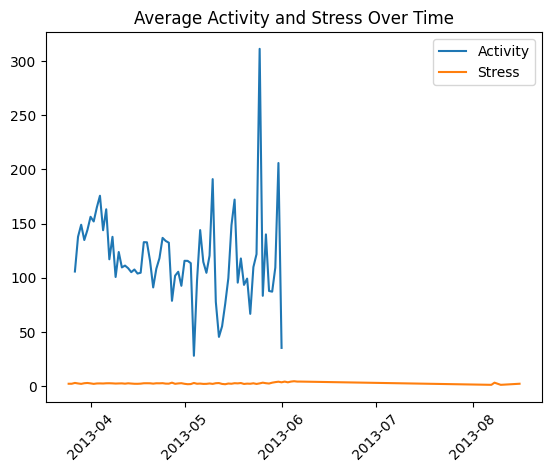

In [243]:
daily_activity = (
    merged_mood.groupby('date')['activity_minutes']
    .mean()
)

daily_stress = (
    merged_mood.groupby('date')['level']
    .mean()
)

import matplotlib.pyplot as plt

plt.figure()

plt.plot(daily_activity.index,
         daily_activity.values,
         label='Activity')

plt.plot(daily_stress.index,
         daily_stress.values,
         label='Stress')

plt.legend()
plt.xticks(rotation=45)

plt.title("Average Activity and Stress Over Time")

plt.show()

In [244]:
daily = merged_mood.groupby('date').agg({
    'level': 'mean',
    'activity_minutes': 'mean',
    'sleep': 'mean',
    'workload': 'mean'
}).reset_index()

In [245]:
for col in ['level', 'activity_minutes', 'sleep', 'workload']:

    daily[col + '_z'] = (
        (daily[col] - daily[col].mean())
        / daily[col].std()
    )

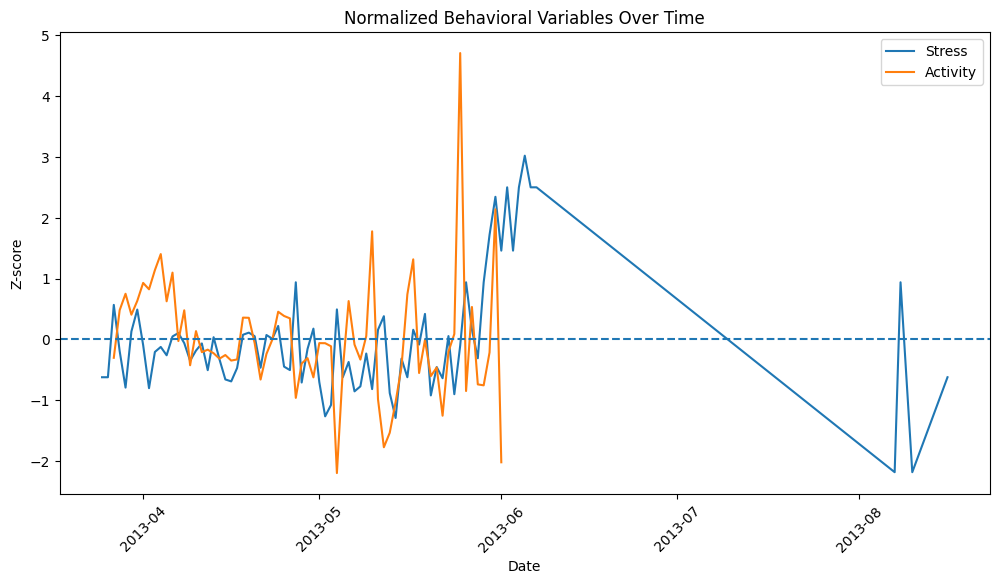

In [246]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    daily['date'],
    daily['level_z'],
    label='Stress'
)

plt.plot(
    daily['date'],
    daily['activity_minutes_z'],
    label='Activity'
)

#plt.plot(
#    daily['date'],
#    daily['sleep_z'],
#    label='Sleep'
#)

#plt.plot(
#    daily['date'],
#    daily['workload_z'],
#    label='Workload'
#)

plt.axhline(0, linestyle='--')

plt.legend()

plt.title("Normalized Behavioral Variables Over Time")

plt.xlabel("Date")
plt.ylabel("Z-score")

plt.xticks(rotation=45)

plt.show()

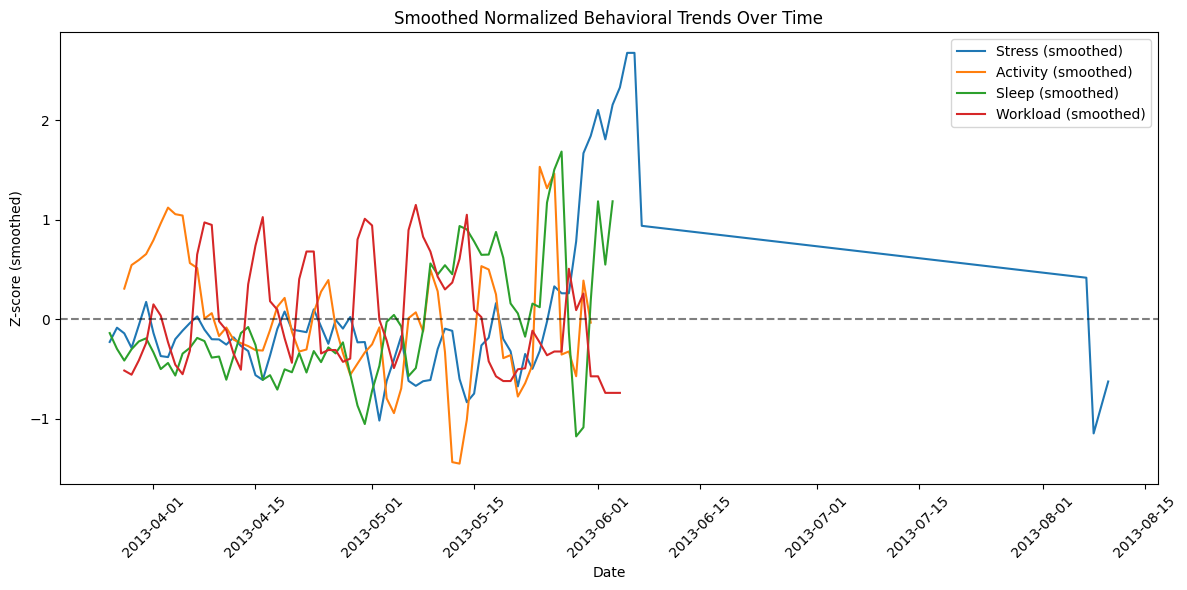

In [247]:
# Smoothen (rolling mean)

window = 3  # 5 for smoother curves

for col in ['level_z', 'activity_minutes_z', 'sleep_z', 'workload_z']:
    daily[col + '_smooth'] = (
        daily[col]
        .rolling(window=window, center=True)
        .mean()
    )

# Plot it

plt.figure(figsize=(12, 6))

plt.plot(daily['date'], daily['level_z_smooth'], label='Stress (smoothed)')
plt.plot(daily['date'], daily['activity_minutes_z_smooth'], label='Activity (smoothed)')
plt.plot(daily['date'], daily['sleep_z_smooth'], label='Sleep (smoothed)')
plt.plot(daily['date'], daily['workload_z_smooth'], label='Workload (smoothed)')

plt.axhline(0, linestyle='--', color='black', alpha=0.5)

plt.title("Smoothed Normalized Behavioral Trends Over Time")
plt.xlabel("Date")
plt.ylabel("Z-score (smoothed)")
plt.xticks(rotation=45)

plt.legend()
plt.tight_layout()
plt.show()

# Make ready for prediction

In [248]:
#It is called merged_mood now instead of merged_clean, sooo we're changing back for now
merged_clean = merged_mood

#Adding day of the week to the datafrmae
merged_clean['date'] = pd.to_datetime(merged_clean['date'])

#Day 0 is monday, 6 is sunday
merged_clean['day_of_week'] = merged_clean['date'].dt.dayofweek
merged_clean['is_weekend'] = merged_clean['day_of_week'] >= 5

merged_clean['month'] = merged_clean['date'].dt.month
merged_clean['week'] = merged_clean['date'].dt.isocalendar().week

In [249]:
list(merged_clean.columns.values)

['user',
 'date',
 'level',
 'workload',
 'high_pressure',
 'social',
 'high_workload',
 'high_social',
 'sleep',
 'good_sleep',
 'baseline_stress',
 'stress_category',
 'mood_valence',
 'happy_now',
 'stressed_now',
 'tired_now',
 'expect_happy',
 'expect_stressed',
 'expect_tired',
 'activity_minutes',
 'day_of_week',
 'is_weekend',
 'month',
 'week']

# Looking a bit at missingness

In [250]:
print("Total observations:", len(merged_clean))

Total observations: 1244


In [251]:
merged_clean.isna().sum()

user                  0
date                  0
level                 0
workload            140
high_pressure         0
social              576
high_workload         0
high_social           0
sleep               397
good_sleep            0
baseline_stress      30
stress_category      30
mood_valence        773
happy_now           737
stressed_now        737
tired_now           737
expect_happy        754
expect_stressed     754
expect_tired        754
activity_minutes     28
day_of_week           0
is_weekend            0
month                 0
week                  0
dtype: int64

In [252]:
merged_clean.loc[
    merged_clean['baseline_stress'].isna(),
    'user'
].unique()

<StringArray>
['u25', 'u39', 'u41']
Length: 3, dtype: str

In [253]:
merged_clean.loc[
    merged_clean['baseline_stress'].isna()
].groupby('user').size()

user
u25    14
u39     6
u41    10
dtype: int64

## Imputing Workload

In [254]:
merged_clean['workload'] = (
    merged_clean.groupby('user')['workload']
    .transform(lambda x: x.fillna(x.median()))
)

## Imputing Physical Activity

In [255]:
merged_clean['activity_minutes'] = (
    merged_clean.groupby('user')['activity_minutes']
    .transform(lambda x: x.fillna(x.median()))
)

## Imputing Sleep Duration

In [256]:
merged_clean['sleep'] = (
    merged_clean.groupby('user')['sleep']
    .transform(lambda x: x.fillna(x.median()))
)

## Imputing Workload as well

In [257]:
#First impute based on user
merged_clean['workload'] = (
    merged_clean.groupby('user')['workload']
    .transform(lambda x: x.fillna(x.median()))
)

#If the user didn't fill in wokrload at all impute based on global median per date
merged_clean['workload'] = (
    merged_clean.groupby('date')['workload']
    .transform(
        lambda x: x.fillna(x.median())
    )
)

#If still NaN impute based on global median
merged_clean['workload'] = (
    merged_clean['workload']
    .fillna(
        merged_clean['workload'].median()
    )
)

## Imputing Social Activity

In [260]:
# Median based on participant and whether it's weekend or not
merged_clean['social'] = (
    merged_clean.groupby(
        ['user', 'is_weekend']
    )['social']
    .transform(
        lambda x: x.fillna(x.median())
    )
)

# If that doesn't do it all, just do it per user (median)
merged_clean['social'] = (
    merged_clean.groupby('user')['social']
    .transform(
        lambda x: x.fillna(x.median())
    )
)

### Check missingness after imputation

In [261]:
merged_clean.isna().sum()

user                  0
date                  0
level                 0
workload              0
high_pressure         0
social                0
high_workload         0
high_social           0
sleep                 0
good_sleep            0
baseline_stress      30
stress_category      30
mood_valence        773
happy_now           737
stressed_now        737
tired_now           737
expect_happy        754
expect_stressed     754
expect_tired        754
activity_minutes      0
day_of_week           0
is_weekend            0
month                 0
week                  0
dtype: int64

# Make data into .csv file

In [262]:
merged_clean.to_csv("data_for_pred3.csv", index=False)

## Desriptive Statistics

In [263]:
descriptive_stats = merged_clean[
    [
        'level',
        'sleep',
        'social',
        'workload',
        'activity_minutes',
        'baseline_stress',
        'mood_valence'
    ]
].describe()

print(descriptive_stats)

             level        sleep       social     workload  activity_minutes  \
count  1244.000000  1244.000000  1244.000000  1244.000000       1244.000000   
mean      2.251531     7.229100     2.972803     0.307074        122.839784   
std       1.222858     1.875687     0.961030     0.598132        104.812372   
min       1.000000     0.000000     1.000000     0.000000          0.000000   
25%       1.000000     6.000000     2.000000     0.000000         67.016667   
50%       2.000000     7.000000     3.000000     0.000000        104.450000   
75%       3.000000     8.000000     4.000000     0.000000        152.833333   
max       5.000000    17.000000     6.000000     3.000000       1440.216667   

       baseline_stress  mood_valence  
count      1214.000000    471.000000  
mean         18.496705      0.258493  
std           6.818546      1.330422  
min           3.000000     -3.000000  
25%          14.000000      0.000000  
50%          19.000000      0.250000  
75%          23

In [265]:
desc = merged_clean[
    [
        'level',
        'sleep',
        'social',
        'workload',
        'activity_minutes',
        'baseline_stress',
        'mood_valence'
    ]
].agg(['count', 'mean', 'std', 'min', 'max']).round(2)

print(desc.T)

                   count    mean     std  min      max
level             1244.0    2.25    1.22  1.0     5.00
sleep             1244.0    7.23    1.88  0.0    17.00
social            1244.0    2.97    0.96  1.0     6.00
workload          1244.0    0.31    0.60  0.0     3.00
activity_minutes  1244.0  122.84  104.81  0.0  1440.22
baseline_stress   1214.0   18.50    6.82  3.0    33.00
mood_valence       471.0    0.26    1.33 -3.0     3.00


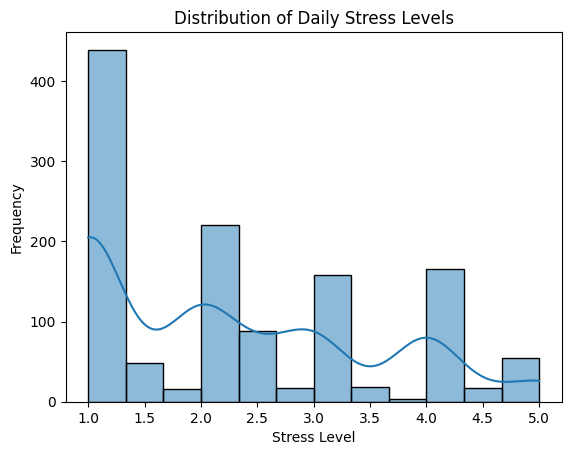

In [267]:
import seaborn as sns

sns.histplot(
    merged_clean['level'],
    kde=True
)

plt.title("Distribution of Daily Stress Levels")
plt.xlabel("Stress Level")
plt.ylabel("Frequency")

plt.show()

### Making a smoothed curve visualization

In [276]:
# Make sure date is datetime
merged_clean['date'] = pd.to_datetime(
    merged_clean['date']
)

# Aggregate daily averages
daily = (
    merged_clean
    .groupby('date')[
        ['level', 'sleep', 'activity_minutes']
    ]
    .mean()
    .reset_index()
)

In [278]:
# Standardize variables
for col in ['level', 'sleep', 'activity_minutes']:

    daily[col + '_z'] = (
        daily[col] - daily[col].mean()
    ) / daily[col].std()

In [279]:
# Smooth curves
window = 5

for col in [
    'level_z',
    'sleep_z',
    'activity_minutes_z'
]:

    daily[col + '_smooth'] = (
        daily[col]
        .rolling(window=window, center=True)
        .mean()
    )

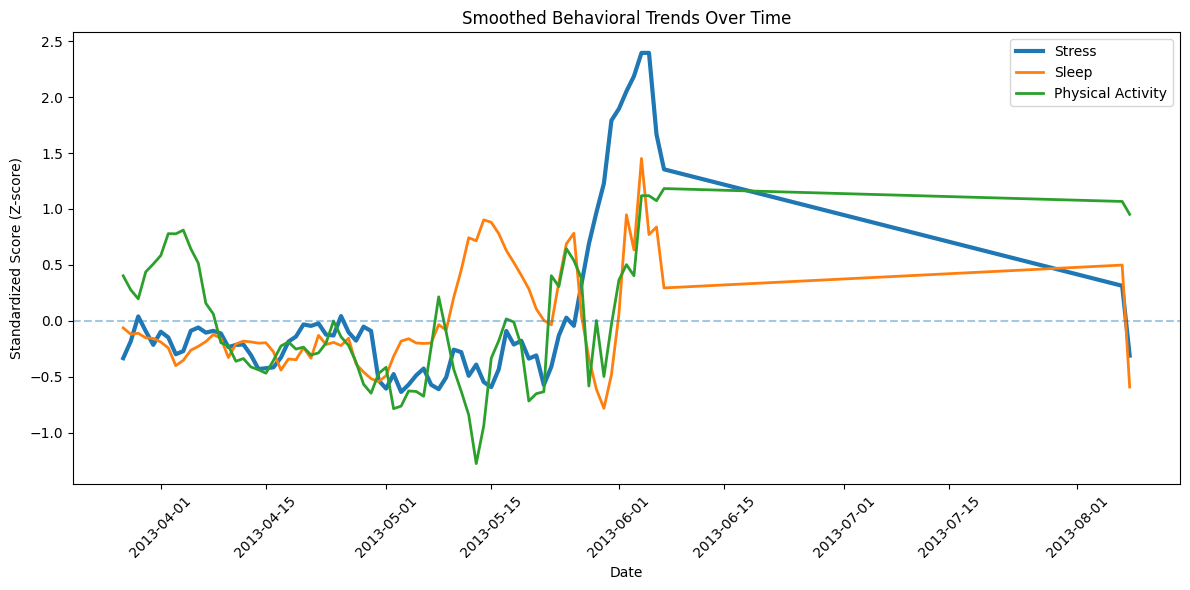

In [280]:
plt.figure(figsize=(12,6))

# Stress
plt.plot(
    daily['date'],
    daily['level_z_smooth'],
    linewidth=3,
    label='Stress'
)

# Sleep
plt.plot(
    daily['date'],
    daily['sleep_z_smooth'],
    linewidth=2,
    label='Sleep'
)

# Activity
plt.plot(
    daily['date'],
    daily['activity_minutes_z_smooth'],
    linewidth=2,
    label='Physical Activity'
)

# Reference line
plt.axhline(
    0,
    linestyle='--',
    alpha=0.4
)

plt.title(
    "Smoothed Behavioral Trends Over Time"
)

plt.xlabel("Date")
plt.ylabel("Standardized Score (Z-score)")

plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()

plt.show()

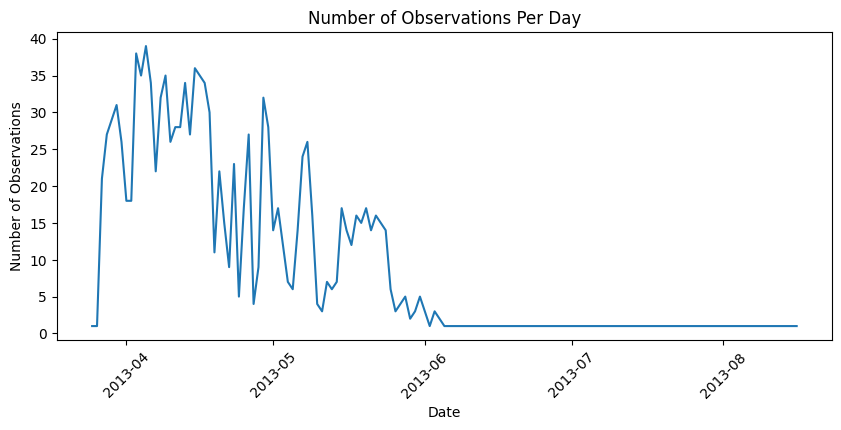

In [281]:
daily_counts = (
    merged_clean
    .groupby('date')
    .size()
)

plt.figure(figsize=(10,4))

plt.plot(daily_counts.index, daily_counts.values)

plt.title("Number of Observations Per Day")
plt.xlabel("Date")
plt.ylabel("Number of Observations")

plt.xticks(rotation=45)

plt.show()

In [277]:
# Smooth curves
window = 5

for col in [
    'level_z',
    'activity_minutes_z',
    'sleep_z'
]:
    daily[col + '_smooth'] = (
        daily[col]
        .rolling(window=window, center=True)
        .mean()
    )

# Plot
plt.figure(figsize=(12,6))

plt.plot(
    daily['date'],
    daily['level_z_smooth'],
    linewidth=3,
    label='Stress'
)

plt.plot(
    daily['date'],
    daily['sleep_z_smooth'],
    linewidth=2,
    label='Sleep'
)

plt.plot(
    daily['date'],
    daily['activity_minutes_z_smooth'],
    linewidth=2,
    label='Physical Activity'
)

plt.axhline(
    0,
    linestyle='--',
    alpha=0.4
)

plt.title(
    "Smoothed Behavioral Trends Over Time"
)

plt.xlabel("Date")
plt.ylabel("Standardized Score (Z-score)")

plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()

plt.show()

KeyError: 'level_z'